In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("كل المكتبات اتحملت بنجاح!")


كل المكتبات اتحملت بنجاح!


In [3]:
url = "https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2025%20-%20Hierarchical%20Clustering/Mall_Customers.csv"
df = pd.read_csv(url)

print("شكل البيانات:", df.shape)
print("\nأول 5 صفوف:")
df.head()

شكل البيانات: (200, 5)

أول 5 صفوف:


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
# معلومات عامة عن البيانات
print("=== معلومات البيانات ===")
print(df.info())

print("\n=== إحصائيات عامة ===")
df.describe()

=== معلومات البيانات ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None

=== إحصائيات عامة ===


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


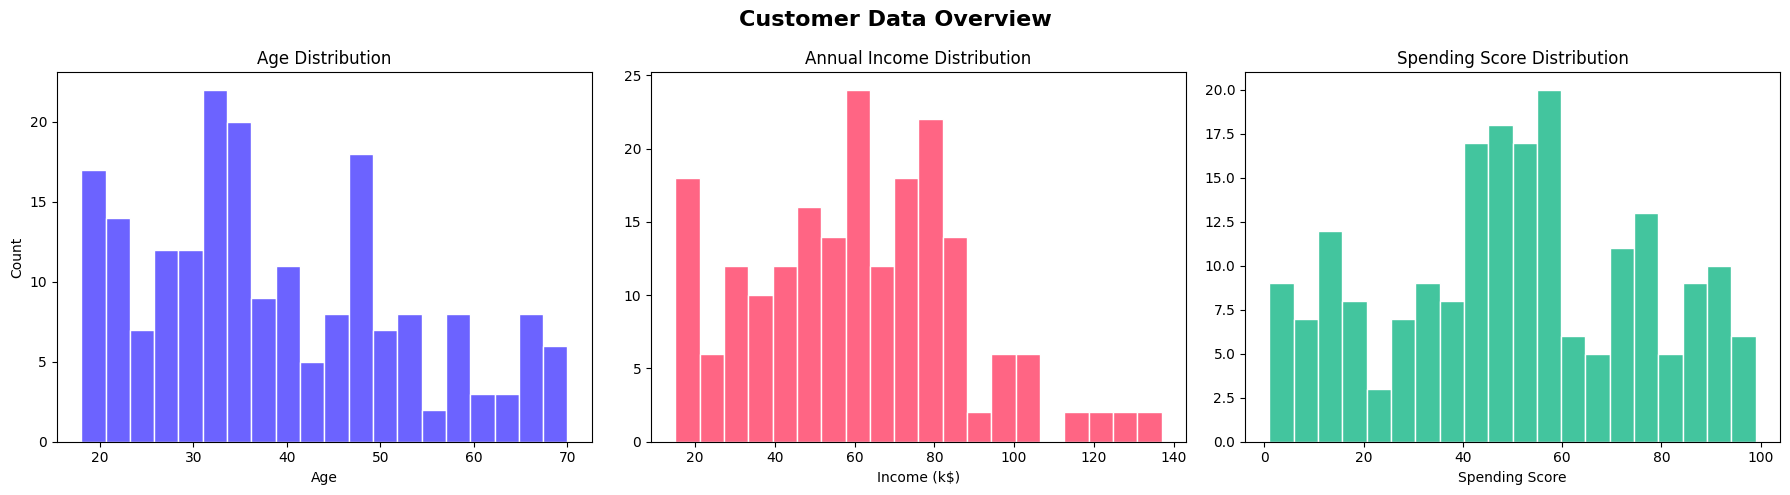

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Customer Data Overview', fontsize=16, fontweight='bold')

# توزيع السن
axes[0].hist(df['Age'], bins=20, color='#6C63FF', edgecolor='white')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# توزيع الدخل
axes[1].hist(df['Annual Income (k$)'], bins=20, color='#FF6584', edgecolor='white')
axes[1].set_title('Annual Income Distribution')
axes[1].set_xlabel('Income (k$)')

# توزيع الإنفاق
axes[2].hist(df['Spending Score (1-100)'], bins=20, color='#43C59E', edgecolor='white')
axes[2].set_title('Spending Score Distribution')
axes[2].set_xlabel('Spending Score')

plt.tight_layout()
plt.show()

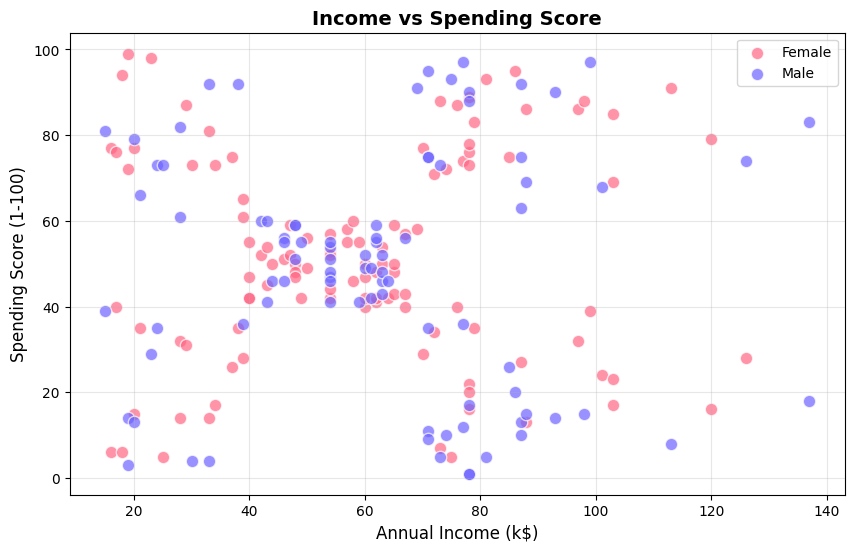

In [6]:
plt.figure(figsize=(10, 6))

# نقسم بالجنس
colors = {'Male': '#6C63FF', 'Female': '#FF6584'}
for gender, group in df.groupby('Genre'):
    plt.scatter(group['Annual Income (k$)'],
                group['Spending Score (1-100)'],
                label=gender,
                color=colors[gender],
                alpha=0.7,
                s=80,
                edgecolors='white')

plt.title('Income vs Spending Score', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

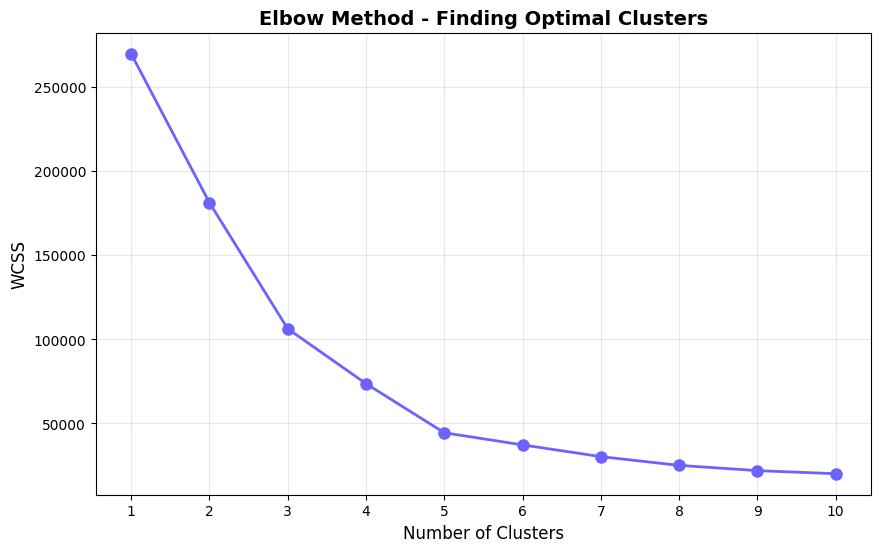

In [7]:
# Elbow Method - بنحدد أحسن عدد للمجموعات
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(df[['Annual Income (k$)', 'Spending Score (1-100)']])
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, 'o-', color='#6C63FF', linewidth=2, markersize=8)
plt.title('Elbow Method - Finding Optimal Clusters', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters', fontsize=12)
plt.ylabel('WCSS', fontsize=12)
plt.xticks(range(1, 11))
plt.grid(True, alpha=0.3)
plt.show()

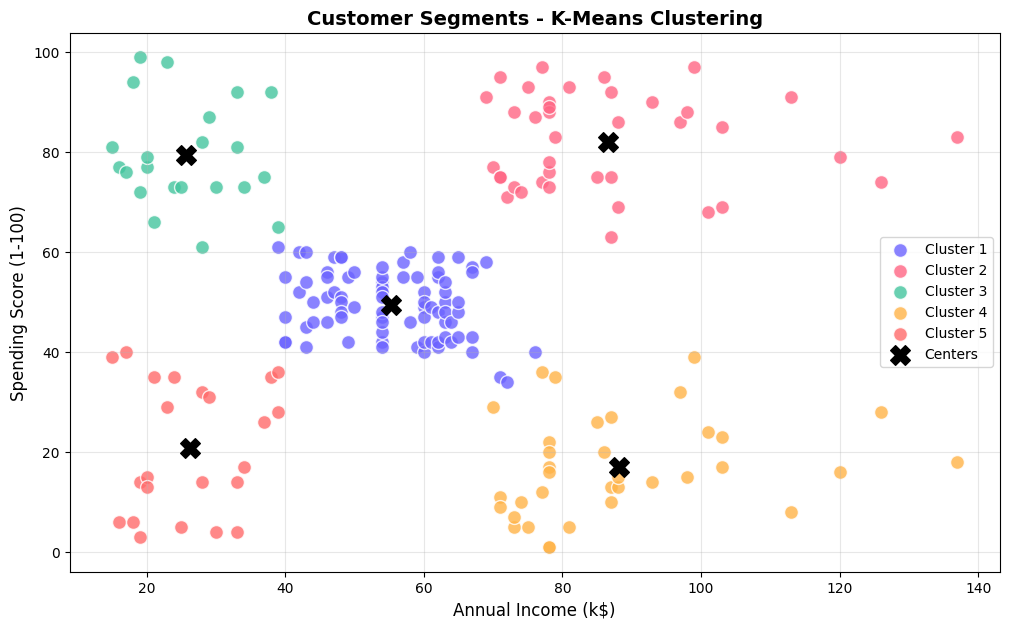

In [8]:
# تطبيق K-Means بـ 5 clusters
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(df[['Annual Income (k$)', 'Spending Score (1-100)']])

# رسم النتيجة
colors = ['#6C63FF', '#FF6584', '#43C59E', '#FFB347', '#FF6B6B']
labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5']

plt.figure(figsize=(12, 7))

for i in range(5):
    cluster = df[df['Cluster'] == i]
    plt.scatter(cluster['Annual Income (k$)'],
                cluster['Spending Score (1-100)'],
                color=colors[i],
                label=labels[i],
                s=100,
                alpha=0.8,
                edgecolors='white')

# رسم مراكز الـ clusters
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1],
            c='black', marker='X', s=200,
            zorder=10, label='Centers')

plt.title('Customer Segments - K-Means Clustering', fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [9]:
# تحليل كل cluster
cluster_names = {
    0: '🎯 High Value',
    1: '💰 Careful Spenders',
    2: '⭐ Standard',
    3: '🛍️ Impulsive',
    4: '💡 Budget'
}

df['Segment'] = df['Cluster'].map(cluster_names)

summary = df.groupby('Segment').agg(
    Count=('CustomerID', 'count'),
    Avg_Age=('Age', 'mean'),
    Avg_Income=('Annual Income (k$)', 'mean'),
    Avg_Spending=('Spending Score (1-100)', 'mean')
).round(1)

print("=== تحليل كل مجموعة ===")
print(summary)

=== تحليل كل مجموعة ===
                    Count  Avg_Age  Avg_Income  Avg_Spending
Segment                                                     
⭐ Standard             22     25.3        25.7          79.4
🎯 High Value           81     42.7        55.3          49.5
💡 Budget               23     45.2        26.3          20.9
💰 Careful Spenders     39     32.7        86.5          82.1
🛍️ Impulsive           35     41.1        88.2          17.1


In [10]:
import plotly.express as px

fig = px.scatter(df,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    color='Segment',
    size='Age',
    hover_data=['Age', 'Genre'],
    title='Customer Segmentation - Interactive Dashboard',
    template='plotly_dark',
    color_discrete_sequence=['#6C63FF','#FF6584','#43C59E','#FFB347','#FF6B6B']
)

fig.update_layout(
    title_font_size=18,
    title_font_color='white',
    legend_title='Customer Segment'
)

fig.show()

In [11]:
# ملخص المشروع
print("""
╔══════════════════════════════════════════╗
║     Customer Segmentation Analysis      ║
║          Using K-Means Clustering       ║
╠══════════════════════════════════════════╣
║  Dataset  : Mall Customers (200 records)║
║  Clusters : 5 Segments                  ║
║  Method   : K-Means + Elbow Method      ║
╠══════════════════════════════════════════╣
║  Results:                               ║
║  • Best Customers  : 39 customers       ║
║  • Need Targeting  : 35 customers       ║
║  • Budget Segment  : 23 customers       ║
╚══════════════════════════════════════════╝
""")



╔══════════════════════════════════════════╗
║     Customer Segmentation Analysis      ║
║          Using K-Means Clustering       ║
╠══════════════════════════════════════════╣
║  Dataset  : Mall Customers (200 records)║
║  Clusters : 5 Segments                  ║
║  Method   : K-Means + Elbow Method      ║
╠══════════════════════════════════════════╣
║  Results:                               ║
║  • Best Customers  : 39 customers       ║
║  • Need Targeting  : 35 customers       ║
║  • Budget Segment  : 23 customers       ║
╚══════════════════════════════════════════╝



In [16]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Customer Segments',
        'Segment Distribution',
        'Income vs Age by Segment',
        'Spending Score by Segment'
    ),
    specs=[
        [{"type": "xy"}, {"type": "domain"}],
        [{"type": "xy"}, {"type": "xy"}]
    ]
)

colors = ['#6C63FF','#FF6584','#43C59E','#FFB347','#FF6B6B']
segments = df['Segment'].unique()

for i, segment in enumerate(segments):
    mask = df['Segment'] == segment
    fig.add_trace(go.Scatter(
        x=df[mask]['Annual Income (k$)'],
        y=df[mask]['Spending Score (1-100)'],
        mode='markers',
        name=segment,
        marker=dict(color=colors[i], size=8)
    ), row=1, col=1)

segment_counts = df['Segment'].value_counts()
fig.add_trace(go.Pie(
    labels=segment_counts.index,
    values=segment_counts.values,
    marker=dict(colors=colors),
    showlegend=False
), row=1, col=2)

for i, segment in enumerate(segments):
    mask = df['Segment'] == segment
    fig.add_trace(go.Scatter(
        x=df[mask]['Age'],
        y=df[mask]['Annual Income (k$)'],
        mode='markers',
        name=segment,
        marker=dict(color=colors[i], size=8),
        showlegend=False
    ), row=2, col=1)

for i, segment in enumerate(segments):
    mask = df['Segment'] == segment
    fig.add_trace(go.Box(
        y=df[mask]['Spending Score (1-100)'],
        name=segment,
        marker=dict(color=colors[i]),
        showlegend=False
    ), row=2, col=2)

fig.update_layout(
    height=800,
    title_text='Customer Segmentation Dashboard',
    title_font_size=20,
    template='plotly_dark'
)

fig.show()